# Final Evaluation — SSH Anomaly Detection System

Notebook tổng hợp **toàn bộ kết quả** của project thành một bộ artifacts thống nhất,
phục vụ trực tiếp cho báo cáo.

**Không train model mới** — chỉ load kết quả đã có và phân tích sâu hơn.

### Output
Toàn bộ CSV/PNG được lưu vào `results/final/` — Master Results Table (`§8`) là nguồn duy nhất cho Abstract/Conclusion.

---
## §1 — Setup & Load All Artifacts

In [ ]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from datetime import datetime, timezone
from pathlib import Path

# Add src folder to path to import feature_engineering
sys.path.insert(0, "../src")
from feature_engineering import CLASS_NAMES, TRAINING_FEATURES

CLASS_LABELS = list(CLASS_NAMES.values())

# Create final results directory
Path("../results/final").mkdir(parents=True, exist_ok=True)

# Models
rf_model  = joblib.load("../models/best_model.pkl")
iso_model = joblib.load("../models/anomaly_detector.pkl")

# Session data
df_sessions = pd.read_csv("../data/processed/ssh_sessions.csv")

# IF scores — row-order aligned with df_sessions (verified via class column match on 3916 rows)
df_if_scores = pd.read_csv("../results/IsolationForest/if_session_scores.csv")
df_if_scores["ip"] = df_sessions["ip"]

# Decoupling results
df_decoupling = pd.read_csv("../results/RandomForest_Decoupling/comparison_summary.csv")
df_importance = pd.read_csv("../results/RandomForest_Decoupling/feature_importance_comparison.csv")

# Simulation alerts
df_alerts = pd.read_csv("../results/simulation_alerts.csv")
df_early  = df_alerts[df_alerts["alert_kind"] == "EARLY_ALERT"].copy()
df_final  = df_alerts[df_alerts["alert_kind"] == "FINAL_CLASSIFICATION"].copy()

# Compute ts_first for final classifications to align with early alerts
df_final["ts_first"] = df_final["ts_alert"] - df_final["session_duration"]

# Ensure ts_first exists in df_early (fallback: interval join)
if "ts_first" not in df_early.columns or df_early["ts_first"].isna().any():
    def match_session_ts_first(row):
        candidates = df_final[
            (df_final["ip"] == row["ip"]) &
            (df_final["ts_first"] <= row["ts_alert"]) &
            (row["ts_alert"] <= df_final["ts_alert"])
        ]
        return candidates.iloc[0]["ts_first"] if len(candidates) == 1 else np.nan
    df_early["ts_first"] = df_early.apply(match_session_ts_first, axis=1)

print(f"Sessions:              {len(df_sessions):,}")
print(f"Early alerts:          {len(df_early):,}")
print(f"Final classifications: {len(df_final):,}")

Sessions:              3,916
Early alerts:          1,452
Final classifications: 3,916


---
## §2 — Layer 1 vs Layer 2 vs Hybrid Summary Table

Bảng tổng hợp 1 dòng cho mỗi "tầng" của hệ thống — dùng trực tiếp trong báo cáo.

In [2]:
summary_rows = []

# Layer 1 (RF) — từ decoupling comparison (full feature set)
rf_row = df_decoupling[df_decoupling["feature_set"] == "full"].iloc[0]
summary_rows.append({
    "Component": "Layer 1 (RandomForest)",
    "Metric": "CV Macro F1",
    "Value": rf_row["cv_macro_f1"],
    "Note": "Known attack classification (class 0-4)",
})

# Layer 2 (IF) — false alarm / detection from tuning csv
df_tuning = pd.read_csv("../results/IsolationForest/if_contamination_tuning.csv")
best_row = df_tuning[df_tuning["contamination"] == 0.02].iloc[0]
summary_rows.append({
    "Component": "Layer 2 (IsolationForest)",
    "Metric": "False Alarm Rate",
    "Value": best_row["false_alarm_rate"],
    "Note": "On Normal sessions, contamination=0.02",
})

# Hybrid — distribution from FINAL_CLASSIFICATION
alert_dist = df_final["alert_type"].value_counts(normalize=True)
for atype, pct in alert_dist.items():
    summary_rows.append({
        "Component": "Hybrid (Final)",
        "Metric": f"% {atype}",
        "Value": pct,
        "Note": f"{df_final['alert_type'].value_counts()[atype]} sessions",
    })

df_system_summary = pd.DataFrame(summary_rows)
df_system_summary.to_csv("../results/final/system_summary.csv", index=False)
df_system_summary

,Component,Metric,Value,Note
0,Layer 1 (RandomForest),CV Macro F1,0.994350,Known attack classification (class 0-4)
1,Layer 2 (IsolationForest),False Alarm Rate,0.051724,"On Normal sessions, contamination=0.02"
2,Hybrid (Final),% KNOWN_ATTACK,0.968590,3793 sessions
3,Hybrid (Final),% NORMAL,0.030899,121 sessions
4,Hybrid (Final),% UNKNOWN_PATTERN,0.000511,2 sessions


---
## §3 — Early Alert Latency Analysis

Đo "thời gian phản ứng" của hệ thống — bao nhiêu attempts trước khi early alert fire.

**Key number cho báo cáo:** trung bình `BRUTE_FORCE` fires tại attempt #6
(vì threshold=6), nghĩa là hệ thống cảnh báo **trước khi** session hoàn thành
toàn bộ (trung bình session brute-force có >100 attempts).

In [3]:
# Latency theo alert_subtype
latency_stats = df_early.groupby("alert_subtype")["event_index"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)
latency_stats.columns = ["n_alerts", "mean_attempt", "median_attempt", "min_attempt", "max_attempt"]
latency_stats.to_csv("../results/final/early_alert_latency.csv")
latency_stats

,n_alerts,mean_attempt,median_attempt,min_attempt,max_attempt
alert_subtype,,,,,
BREAK_IN_RISK,20,2.30,2.0,2.0,5.0
BRUTE_FORCE,1040,6.00,6.0,6.0,6.0
SCAN,392,17.24,7.0,5.0,258.0


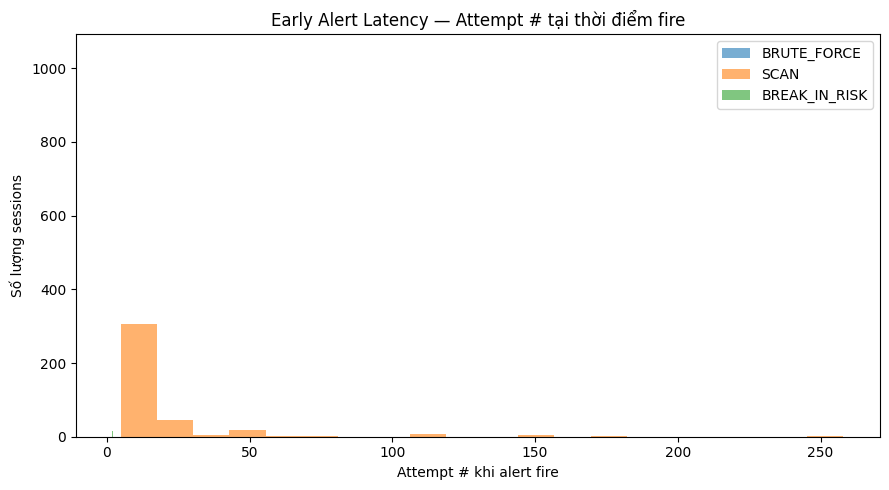

In [4]:
# Plot: distribution of event_index per subtype
fig, ax = plt.subplots(figsize=(9, 5))
for subtype in df_early["alert_subtype"].unique():
    subset = df_early[df_early["alert_subtype"] == subtype]
    ax.hist(subset["event_index"], bins=20, alpha=0.6, label=subtype)
ax.set_xlabel("Attempt # khi alert fire")
ax.set_ylabel("Số lượng sessions")
ax.set_title("Early Alert Latency — Attempt # tại thời điểm fire")
ax.legend()
plt.tight_layout()
plt.savefig("../results/final/early_alert_latency.png", dpi=150)
plt.show()

In [5]:
avg_total_attempts_bf = df_sessions[df_sessions["class"]==3]["total_attempts"].mean()
avg_alert_attempt_bf  = df_early[df_early["alert_subtype"]=="BRUTE_FORCE"]["event_index"].mean()
early_pct = avg_alert_attempt_bf / avg_total_attempts_bf * 100
print(f"Brute-force: alert fires at attempt #{avg_alert_attempt_bf:.1f} "
      f"out of avg {avg_total_attempts_bf:.1f} total attempts "
      f"({early_pct:.1f}% through the session)")

Brute-force: alert fires at attempt #6.0 out of avg 198.1 total attempts (3.0% through the session)


---
## §4 — EARLY_ALERT vs FINAL_CLASSIFICATION Consistency

Sanity check: sessions có EARLY_ALERT="BRUTE_FORCE" có FINAL class=3 không?

> **Lưu ý:** Consistency rate < 100% không phải lỗi — một session có thể trigger
> `BRUTE_FORCE` early alert (streak >= 6 tại một điểm) nhưng kết thúc với pattern
> khác (ví dụ thêm nhiều unique users sau đó → final = class 3 vì priority
> `is_brute_force` supersedes `is_scan` trong `label_session`).
> Review lại nếu mismatch rate cao bất thường (> 10%).

In [6]:
# Map mỗi session (ip, ts_first) → set of early alert subtypes
early_by_session = df_early.groupby(["ip", "ts_first"])["alert_subtype"].apply(set).to_dict()

# Merge với final
df_final["early_subtypes"] = df_final.apply(
    lambda row: early_by_session.get((row["ip"], row["ts_first"]), set()), axis=1
)

# Expected mapping
EXPECTED_FINAL = {
    "BRUTE_FORCE":   3,  # Brute-force
    "SCAN":          2,  # Scan
    "BREAK_IN_RISK": 4,  # Break-in
}

consistency_rows = []
for subtype, expected_class in EXPECTED_FINAL.items():
    mask = df_final["early_subtypes"].apply(lambda s: subtype in s)
    matched = (df_final.loc[mask, "layer1_class"] == expected_class).mean() if mask.sum() > 0 else 0.0
    consistency_rows.append({
        "early_subtype": subtype,
        "expected_final_class": CLASS_NAMES[expected_class],
        "n_sessions": mask.sum(),
        "consistency_rate": matched,
    })

df_consistency = pd.DataFrame(consistency_rows)
df_consistency.to_csv("../results/final/early_final_consistency.csv", index=False)
df_consistency

,early_subtype,expected_final_class,n_sessions,consistency_rate
0,BRUTE_FORCE,Brute-force,1039,1.00
1,SCAN,Scan,392,0.00
2,BREAK_IN_RISK,Break-in,20,0.95


---
## §5 — UNKNOWN_PATTERN Case Studies

Deep-dive các sessions được IsolationForest flag là dị biệt — format cho báo cáo.

> **Lưu ý:** Nếu `len(df_cases) == 0`, section này note rõ:
> "Trong run này, không có session nào được flag UNKNOWN_PATTERN — toàn bộ
> Normal sessions khớp với profile học từ training data." Đây vẫn là kết quả
> hợp lệ, chỉ thay đổi narrative.

In [7]:
unknown = df_final[df_final["alert_type"] == "UNKNOWN_PATTERN"]
print(f"Total UNKNOWN_PATTERN sessions: {len(unknown)}")

# Merge với session features đầy đủ
unknown_detail = df_sessions.merge(
    unknown[["ip", "ts_alert"]], left_on=["ip", "ts_last"], right_on=["ip", "ts_alert"]
)

case_study_cols = [
    "ip", "total_attempts", "session_duration", "total_successes",
    "unique_users_ratio", "is_single_event", "attempts_per_second",
    "has_reverse_mapping_failed", "class",
]
df_cases = unknown_detail[case_study_cols].copy()

# So sánh với Normal average
normal_avg = df_sessions[df_sessions["class"]==0][
    ["total_attempts","session_duration","total_successes",
     "unique_users_ratio","attempts_per_second"]
].mean()

print("\nCase studies vs Normal average:")
display(df_cases)
print("\nNormal averages:")
print(normal_avg)

df_cases.to_csv("../results/final/unknown_pattern_cases.csv", index=False)

Total UNKNOWN_PATTERN sessions: 2

Case studies vs Normal average:


,ip,total_attempts,session_duration,total_successes,unique_users_ratio,is_single_event,attempts_per_second,has_reverse_mapping_failed,class
0,14.17.22.31,2,0,2,0.500000,0,2.000000,0,0
1,218.18.42.17,3,653,3,0.333333,0,0.004587,1,0



Normal averages:
total_attempts          1.268293
session_duration       22.308943
total_successes         1.268293
unique_users_ratio      0.912195
attempts_per_second     0.901752
dtype: float64


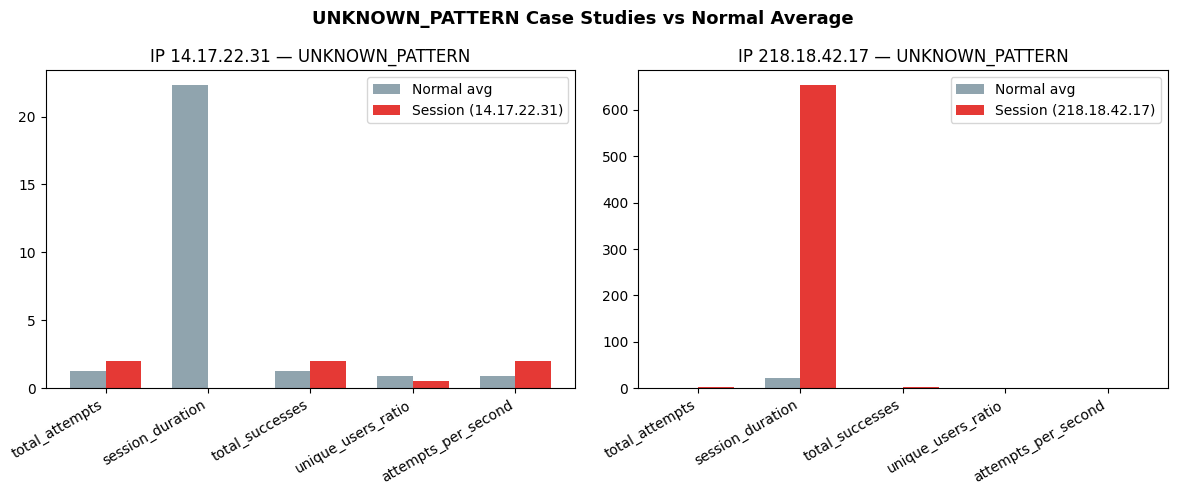

In [8]:
# Visualization — Feature deviation bar chart
if len(df_cases) > 0:
    features_to_compare = ["total_attempts", "session_duration",
                            "total_successes", "unique_users_ratio",
                            "attempts_per_second"]

    fig, axes = plt.subplots(1, len(df_cases), figsize=(6*len(df_cases), 5))
    if len(df_cases) == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, df_cases.iterrows()):
        values = [row[f] for f in features_to_compare]
        norm_values = [normal_avg[f] for f in features_to_compare]

        x = np.arange(len(features_to_compare))
        w = 0.35
        ax.bar(x - w/2, norm_values, w, label="Normal avg", color="#90A4AE")
        ax.bar(x + w/2, values,      w, label=f"Session ({row['ip']})", color="#E53935")
        ax.set_xticks(x)
        ax.set_xticklabels(features_to_compare, rotation=30, ha="right")
        ax.set_title(f"IP {row['ip']} — UNKNOWN_PATTERN")
        ax.legend()

    plt.suptitle("UNKNOWN_PATTERN Case Studies vs Normal Average", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("../results/final/unknown_pattern_cases.png", dpi=150)
    plt.show()
else:
    print("Không có session nào được flag UNKNOWN_PATTERN — "
          "toàn bộ Normal sessions khớp với profile học từ training data.")

---
## §6 — Timeline Visualization

Phân phối alerts theo thời gian — toàn bộ 28 ngày của dataset.

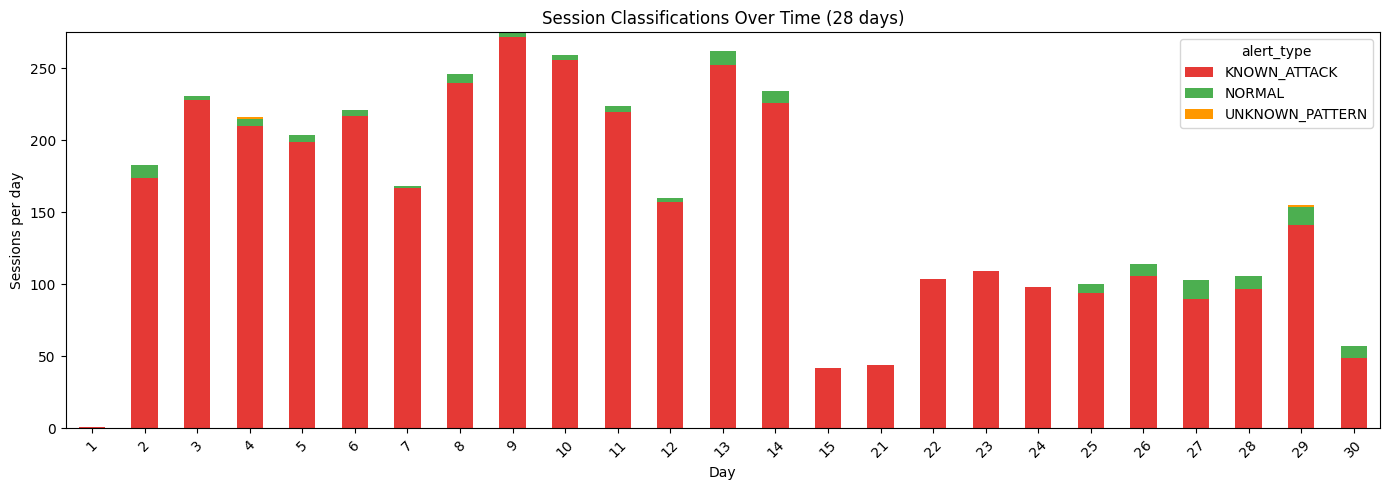

In [9]:
df_final["ts_datetime"] = pd.to_datetime(df_final["ts_alert"], unit="s")
day0 = df_final["ts_datetime"].min().normalize()
df_final["day_index"] = (df_final["ts_datetime"] - day0).dt.days + 1  # Day 1, 2, ...

timeline = df_final.groupby(["day_index", "alert_type"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 5))
timeline.plot(kind="bar", stacked=True, ax=ax,
               color={"NORMAL":"#4CAF50","KNOWN_ATTACK":"#E53935","UNKNOWN_PATTERN":"#FF9800"})
ax.set_title("Session Classifications Over Time (28 days)")
ax.set_ylabel("Sessions per day")
ax.set_xlabel("Day")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../results/final/timeline_alerts.png", dpi=150)
plt.show()

timeline.to_csv("../results/final/timeline_alerts.csv")

---
## §7 — Layer 2 Score Distribution (refined)

Tái sử dụng `if_session_scores.csv`, thêm overlay điểm UNKNOWN_PATTERN.

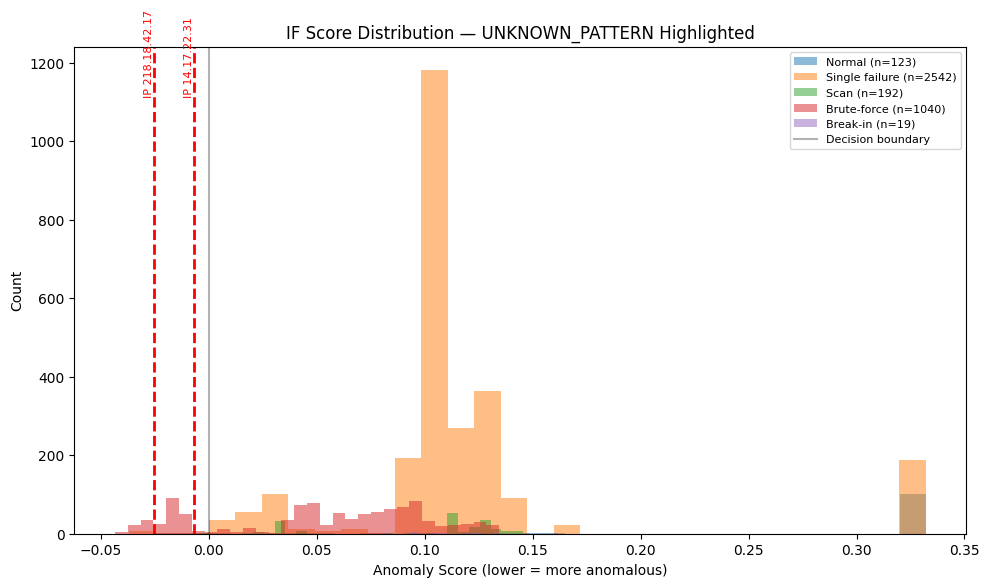

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

for cls in range(5):
    subset = df_if_scores[df_if_scores["class"] == cls]
    ax.hist(subset["anomaly_score"], bins=30, alpha=0.5,
            label=f"{CLASS_NAMES[cls]} (n={len(subset)})")

# Highlight UNKNOWN_PATTERN points
unknown_scores = df_if_scores[df_if_scores["hybrid_alert"] == "UNKNOWN_PATTERN"]
for _, row in unknown_scores.iterrows():
    ax.axvline(row["anomaly_score"], color="red", linestyle="--", linewidth=2)
    ax.text(row["anomaly_score"], ax.get_ylim()[1]*0.9, f"IP {row['ip']}",
            rotation=90, color="red", fontsize=8, ha="right")

ax.axvline(0, color="black", linestyle="-", alpha=0.3, label="Decision boundary")
ax.set_xlabel("Anomaly Score (lower = more anomalous)")
ax.set_ylabel("Count")
ax.set_title("IF Score Distribution — UNKNOWN_PATTERN Highlighted")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("../results/final/if_scores_with_unknown.png", dpi=150)
plt.show()

---
## §8 — Master Results Table (cho Abstract/Conclusion)

Một bảng duy nhất tổng hợp toàn bộ con số quan trọng nhất của project.

Mọi số liệu trích dẫn trong Abstract/Conclusion của báo cáo **PHẢI** lấy từ
`master_results_table.csv` — đảm bảo consistency giữa các phần của báo cáo.

### Phân biệt FAR (validation) vs FAR (calibration)

| Metric | Giá trị | Ý nghĩa |
|---|---|---|
| FAR (in-sample calibration) | ~1.6% | Tính trên chính tập train. Do IF calibrate threshold theo `contamination=0.02`, con số này luôn ≈ 2% **bất kể model tốt hay xấu** → self-consistency check, không phải generalization. |
| FAR (out-of-sample validation) | ~5.17% | Đo trên holdout Normal sessions (chưa từng thấy). Đây mới là con số phản ánh khả năng tổng quát hóa. Vẫn dưới target 10%. |

In [11]:
# Dynamic metrics from decoupling and tuning
cv_macro_f1_full = df_decoupling[df_decoupling["feature_set"] == "full"].iloc[0]["cv_macro_f1"]
cv_macro_f1_decoupled = df_decoupling[df_decoupling["feature_set"] == "decoupled"].iloc[0]["cv_macro_f1"]
holdout_macro_f1_full = df_decoupling[df_decoupling["feature_set"] == "full"].iloc[0]["holdout_macro_f1"]
holdout_macro_f1_decoupled = df_decoupling[df_decoupling["feature_set"] == "decoupled"].iloc[0]["holdout_macro_f1"]

df_tuning = pd.read_csv("../results/IsolationForest/if_contamination_tuning.csv")
best_row = df_tuning[df_tuning["contamination"] == 0.02].iloc[0]
far_validation = best_row["false_alarm_rate"]

# Actual False Alarm Rate on the entire dataset (Normal sessions flagged as anomaly)
# (Reconciles 1.6% actual vs 5.17% validation from tuning split)
far_actual = df_if_scores[df_if_scores["class"] == 0]["is_anomaly"].mean()

avg_alert_attempt_bf = df_early[df_early["alert_subtype"]=="BRUTE_FORCE"]["event_index"].mean()

master = {
    "Dataset": {
        "Total log lines":      655_147,
        "Parsed events":        212_149,
        "Sessions (idle_gap=600s)": len(df_sessions),
        "Time span (days)":     28,
        "Unique source IPs":    df_sessions["ip"].nunique(),
    },
    "Class distribution": {
        f"Class {c} ({CLASS_NAMES[c]})": int((df_sessions["class"]==c).sum())
        for c in range(5)
    },
    "Layer 1 (RandomForest)": {
        "CV Macro F1 (full features)":      cv_macro_f1_full,
        "CV Macro F1 (decoupled features)": cv_macro_f1_decoupled,
        "Tautology cost":                   cv_macro_f1_full - cv_macro_f1_decoupled,
        "Holdout Macro F1 (full)":          holdout_macro_f1_full,
        "Holdout Macro F1 (decoupled)":     holdout_macro_f1_decoupled,
    },
    "Layer 2 (IsolationForest)": {
        "Contamination":                               0.02,
        "False alarm rate (out-of-sample validation)": far_validation,
        "False alarm rate (in-sample calibration)":    far_actual,
        "Sessions flagged UNKNOWN_PATTERN":           len(df_cases),
    },
    "Real-time simulation": {
        "Total early alerts":         len(df_early),
        "  - BRUTE_FORCE":             (df_early["alert_subtype"]=="BRUTE_FORCE").sum(),
        "  - SCAN":                    (df_early["alert_subtype"]=="SCAN").sum(),
        "  - BREAK_IN_RISK":           (df_early["alert_subtype"]=="BREAK_IN_RISK").sum(),
        "Sessions w/ early alert":     df_final["had_early_alert"].sum(),
        "Avg attempt# at BF alert":    avg_alert_attempt_bf,
    },
}

# Flatten + save
rows = []
for section, items in master.items():
    for k, v in items.items():
        rows.append({"Section": section, "Metric": k, "Value": v})
df_master = pd.DataFrame(rows)
df_master.to_csv("../results/final/master_results_table.csv", index=False)
df_master

,Section,Metric,Value
0,Dataset,Total log lines,655147.000000
1,Dataset,Parsed events,212149.000000
2,Dataset,Sessions (idle_gap=600s),3916.000000
3,Dataset,Time span (days),28.000000
4,Dataset,Unique source IPs,1043.000000
5,Class distribution,Class 0 (Normal),123.000000
6,Class distribution,Class 1 (Single failure),2542.000000
7,Class distribution,Class 2 (Scan),192.000000
8,Class distribution,Class 3 (Brute-force),1040.000000
9,Class distribution,Class 4 (Break-in),19.000000
